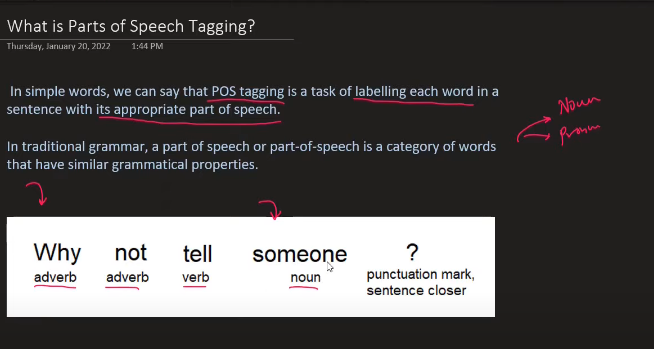

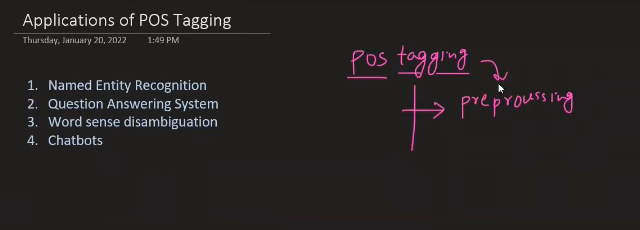



## Full Summary: Part of Speech Tagging (POS)

### 1. Definition and Applications of POS Tagging

Part of Speech (POS) Tagging is a fundamental task in Natural Language Processing (NLP). In simple terms, it is the process of labeling each word in an input sentence with its appropriate part of speech. Parts of speech are categories of words (like noun, pronoun, verb, adjective) that share similar grammatical properties.

POS Tagging is an essential **preprocessing step** in the NLP pipeline, crucial for preparing data for analysis. It helps machines syntactically understand the meaning of language.

**Key Applications of POS Tagging:**

*   **Complex Analysis Tools:** It is required for building sophisticated systems like chatbots, Question Answering systems, and Information Retrieval systems.
*   **Named Entity Recognition (NER):** POS tagging is used to help extract entities (like people, places, or dates) from text (e.g., extracting "Rahul," "Delhi," and "30th March" as entities).
*   **Word Sense Disambiguation:** It helps decode when the same word is used with different meanings in different contexts (e.g., distinguishing the meaning of "left" in "I left the room" vs. "The left fell off the room").

### 2. Spacy Implementation (Code Details)

The video transcript demonstrates how to perform POS tagging easily using the Spacy library. Spacy handles the complex background work automatically.

#### A. Setup and Loading the Model

To begin, one must install Spacy (using `pip install spacy`) and then import the library.

The next step is to load the English language dictionary using the following code, storing it in an object (often named `nlp`):
```python
import spacy
nlp = spacy.load("en_core_web_sm")
```


#### B. Tagging and Accessing Attributes

When a document (sentence) is passed to the loaded object, POS tagging automatically occurs behind the scenes.

```python
doc = nlp("I will google about facebook")
```


Words in the document can be accessed using list-like indexing (e.g., `doc` returns 'I').

Spacy provides two levels of detail for POS tags:

1.  **Coarse-Grained Parts of Speech:** This provides a broad classification (e.g., VERB, NOUN). It is accessed using the **`.pos_`** attribute.
    *   *Example:* `doc.pos_` returns `PRONOUN`.

2.  **Fine-Grained Parts of Speech:** This provides more specific details (e.g., differentiating between singular present verbs and past participles). It is accessed using the **`.tag_`** attribute.
    *   *Example:* When comparing "I read a book" (present tense verb) and "I have read a book" (past participle), Spacy accurately assigns different fine-grained tags, showing its precision.

The full form of a fine-grained tag can be looked up using the `explain` function:
```python
nlp.vocab.explain('PRP')  # Example output: 'pronoun, personal'
```


#### C. Word-by-Word Analysis and Visualization

A loop can be used to iterate through the document and print all details for each word:

```python
for word in doc:
    print(word.text, "->", word.pos_, "->", word.tag_, "->", spacy.explain(word.tag_))
```


For visualization, the `displacy` utility from Spacy can be used to visually render the POS tags and dependencies:

```python
from spacy import displacy
displacy.render(doc, style="dep", jupyter=True)
```


### 3. Internal Mechanism: Hidden Markov Models (HMM) and Probabilities

Internally, complex libraries like Spacy often use powerful, probability-based algorithms, most notably the **Hidden Markov Model (HMM)**, to perform POS tagging.

#### A. Training and Key Probabilities

An HMM must first be trained on manually tagged data. The training process calculates two crucial sets of probabilities:

**1. Emission Probability**
The Emission Probability dictates the likelihood that a given word belongs to a specific POS tag.

$$P(\text{Word} \mid \text{POS})$$

This is calculated by counting how many times a word appears under a certain POS and dividing by the total count of that POS.
*   *Example:* If the POS is Noun, the probability of the word "Niatesh" being that Noun is $2/10$ (since Noun totals 10 counts, and "Niatesh" appeared 2 times as a Noun).

| Word | Noun Count | Model Count | Verb Count | Emission Probability (P(Word|POS)) |
| :--- | :--- | :--- | :--- | :--- |
| Niatesh | 2 | 0 | 0 | $2/10$ (Noun total) |
| Luvs | 0 | 0 | 3 | $3/5$ (Verb total) |
| Will | 2 | 1 | 0 | $2/10$ (Noun), $1/2$ (Model) |

**2. Transition Probability**
The Transition Probability dictates the likelihood of moving from one POS tag to another (e.g., the probability that a Noun will be followed by a Verb). To calculate this, 'Start' and 'End' tags are added to the training sentences.

$$P(\text{POS}_2 \mid \text{POS}_1)$$

*   *Example:* Based on the training data, the probability of Noun being followed by a Verb $P(\text{Verb} \mid \text{Noun})$ was $5/10$. The probability of Model being followed by a Noun $P(\text{Noun} \mid \text{Model})$ was $2/2$ (or 1).

#### B. The Challenge of Brute Force

When applying the HMM to a new sentence (e.g., "Will will Google CampusX"), the goal is to find the sequence of tags that yields the highest overall probability. This overall probability is the product of all conditional probabilities (Emissions multiplied by Transitions) in the sequence.

If a sentence has $L$ words and there are $N$ possible POS tags, the number of possible combinations (paths) is **$N^L$**. For example, a 4-word sentence with 3 possible tags results in $3^4 = 81$ combinations. This exponential growth makes checking every combination impossible for longer sentences or more complex tag sets.

### 4. Viterbi Algorithm (Optimization and Calculation)

The **Viterbi Algorithm** is an optimization used with the HMM to avoid the exponentially costly brute-force approach. It uses dynamic programming to quickly calculate the most probable POS sequence.

#### Mechanism and Steps:

1.  **Tracking Optimal Paths:** Viterbi starts from the 'Start' state and proceeds word by word, tag by tag.
2.  **Local Optimization:** At every subsequent POS tag (node), the algorithm calculates the cumulative probability (Transition $\times$ Emission) for all paths leading to that node.
3.  **Path Elimination:** When multiple paths reach the same node, Viterbi **retains only the path with the highest probability** and eliminates all others. If any transition or emission probability along a path is zero, that path is immediately eliminated (zeroed out).
4.  **Backtracking:** Once the algorithm reaches the 'End' state, only a single optimal path remains. The final POS tagging is determined by **backtracking** through this highest-probability path from the End state back to the Start state.

By continuously eliminating suboptimal paths at every step, the Viterbi Algorithm significantly speeds up the computation, avoiding the need to test every single possible $N^L$ sequence.

*   *Example Sequence:* For the sentence "Will will Google CampusX", the optimal path found might be: Start $\rightarrow$ Model $\rightarrow$ Noun $\rightarrow$ Verb $\rightarrow$ Noun $\rightarrow$ End.



## Code Summary: Spacy Implementation for POS Tagging

The implementation focuses on using the Spacy library, which handles the complex background work automatically.

### 1. Setup and Initialization

To use Spacy for POS tagging, the following steps and commands are required:

| Purpose | Code / Command | Source | Details |
| :--- | :--- | :--- | :--- |
| **Installation** | `pip install spacy` | | Installs the Spacy library (if not already present). |
| **Import** | `import spacy` | | Imports the necessary library. |
| **Load Dictionary** | `nlp = spacy.load("en_core_web_sm")` | | Loads the English language dictionary (`en_core_web_sm`) into an object, typically named `nlp`. |

### 2. Document Creation and Indexing

After loading the model, a document (sentence) is passed to the loaded object, triggering automatic POS tagging "behind the scenes".

| Purpose | Code Example | Source | Details |
| :--- | :--- | :--- | :--- |
| **Document Creation** | `doc = nlp("I will google about facebook")` | | The resulting `doc` object contains the tagged sentence. |
| **Accessing Full Text** | `doc.text` | | Returns the entire sentence string. |
| **Indexing Words** | `doc` or `doc[-1]` | | Allows extracting individual words/tokens from the document using list-like indexing (e.g., `doc` returns 'I'; `doc[-1]` returns 'facebook'). |

### 3. Accessing Part of Speech Tags

Spacy provides attributes to access both coarse-grained and fine-grained POS tags.

| Attribute | Description | Granularity | Example Use |
| :--- | :--- | :--- | :--- |
| **`.pos_`** | Accesses the **Coarse-Grained** Parts of Speech. | Broad classification (e.g., PRONOUN, VERB). | `doc.pos_` (Returns `PROUN`). |
| **`.tag_`** | Accesses the **Fine-Grained** Parts of Speech. | Detailed grammatical categorization (e.g., differentiating singular present verbs from past participles). | `doc.tag_` (Returns `PRP`). |
| **Tag Explanation** | Function used to look up the full form of a fine-grained tag. | N/A | `nlp.vocab.explain('PRP')` (Returns 'pronoun, personal'). |

### 4. Word-by-Word Analysis (Looping)

To analyze the POS tags for every word in the document, a loop structure is used:

```python
for word in doc:
    print(word.text, "->", word.pos_, "->", word.tag_, "->", spacy.explain(word.tag_))
```
This loop prints the word text, the coarse-grained tag, the fine-grained tag, and the full explanation of the fine-grained tag for each token.

### 5. Visualization using Displacy

Spacy's `displacy` utility is used to visually represent the POS tags and dependencies.

| Purpose | Code / Command | Source |
| :--- | :--- | :--- |
| **Import Displacy** | `from spacy import displacy` | |
| **Render Visualization (Basic)** | `displacy.render(doc, style="dep", jupyter=True)` | |
| **Customize Visualization** | Options can be provided via an `options` dictionary to change display parameters (e.g., reducing distance, setting background color, or font color). | |

In [ ]:
pip install spacy
import spacy

In [ ]:
nlp = spacy.load('en_core_web_sm')
doc = nlp("i will google about facebook")

In [ ]:
docs.text

In [ ]:
docs[0]

In [ ]:
doc[0].pos_

In [ ]:
doc[0].tag_

In [ ]:
spacy.explain('PRP')